In [2]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from utils import get_storey_mid

pd.set_option("display.max_columns", None)

curr_dir = Path.cwd()
DATA_DIR = curr_dir.parent.parent 


df = pd.read_csv(DATA_DIR / "data/merged_resale_prices.csv")

In [3]:
df.flat_model.unique()

<StringArray>
[        'NEW GENERATION',               'IMPROVED',                'MODEL A',
               'STANDARD',              'APARTMENT',     'MODEL A-MAISONETTE',
             'MAISONETTE',             'SIMPLIFIED',                'TERRACE',
                 '2-ROOM',    'IMPROVED-MAISONETTE',       'MULTI GENERATION',
      'PREMIUM APARTMENT',         'New Generation',               'Improved',
                'Model A',               'Standard',              'Apartment',
             'Maisonette',             'Simplified',     'Model A-Maisonette',
       'Multi Generation',          'Adjoined flat',      'Premium Apartment',
                'Terrace',    'Improved-Maisonette',     'Premium Maisonette',
                 '2-room',               'Model A2',                   'DBSS',
                'Type S1',                'Type S2', 'Premium Apartment Loft',
                   '3Gen']
Length: 34, dtype: str

# Read df
we only need information about lease commence date, floor area and flat type. Resale value, time of transactions are irrelevant to answer if flats have become smaller. Flat model may be relevant but we want to see flat type have been becoming smaller

In [4]:
subset_df = df[["flat_type", "floor_area_sqm", "lease_commence_date"]].drop_duplicates()

In [5]:
grouped_df = subset_df.groupby(["flat_type", "lease_commence_date"])["floor_area_sqm"].agg(
    min_floor_area = "min",
    max_floor_area = "max",
    median_floor_area = "median"
).reset_index()
grouped_df.groupby(["flat_type"])["lease_commence_date"].agg(
    min_year= "min",
    max_year= "max"
)

,min_year,max_year
flat_type,,
1 ROOM,1969,1977
2 ROOM,1967,2022
3 ROOM,1966,2022
4 ROOM,1967,2022
5 ROOM,1967,2022
EXECUTIVE,1976,2004
MULTI-GENERATION,1987,1988


Since 1 Room, multi-generation and executive have been stopped, it is difficult to answer the question. For now can exclude them, especially 1 room and multi-generation

In [6]:
filtered_df = grouped_df[grouped_df["flat_type"].isin(["2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM"])]

In [7]:
filtered_df

,flat_type,lease_commence_date,min_floor_area,max_floor_area,median_floor_area
3,2 ROOM,1967,37.0,55.0,45.0
4,2 ROOM,1968,38.0,61.0,47.0
5,2 ROOM,1969,37.0,49.0,42.5
6,2 ROOM,1970,39.0,58.0,47.5
7,2 ROOM,1971,34.0,66.0,45.5
...,...,...,...,...,...
198,5 ROOM,2018,112.0,121.0,114.5
199,5 ROOM,2019,112.0,123.0,116.0
200,5 ROOM,2020,107.0,123.0,117.5
201,5 ROOM,2021,108.0,120.0,113.5


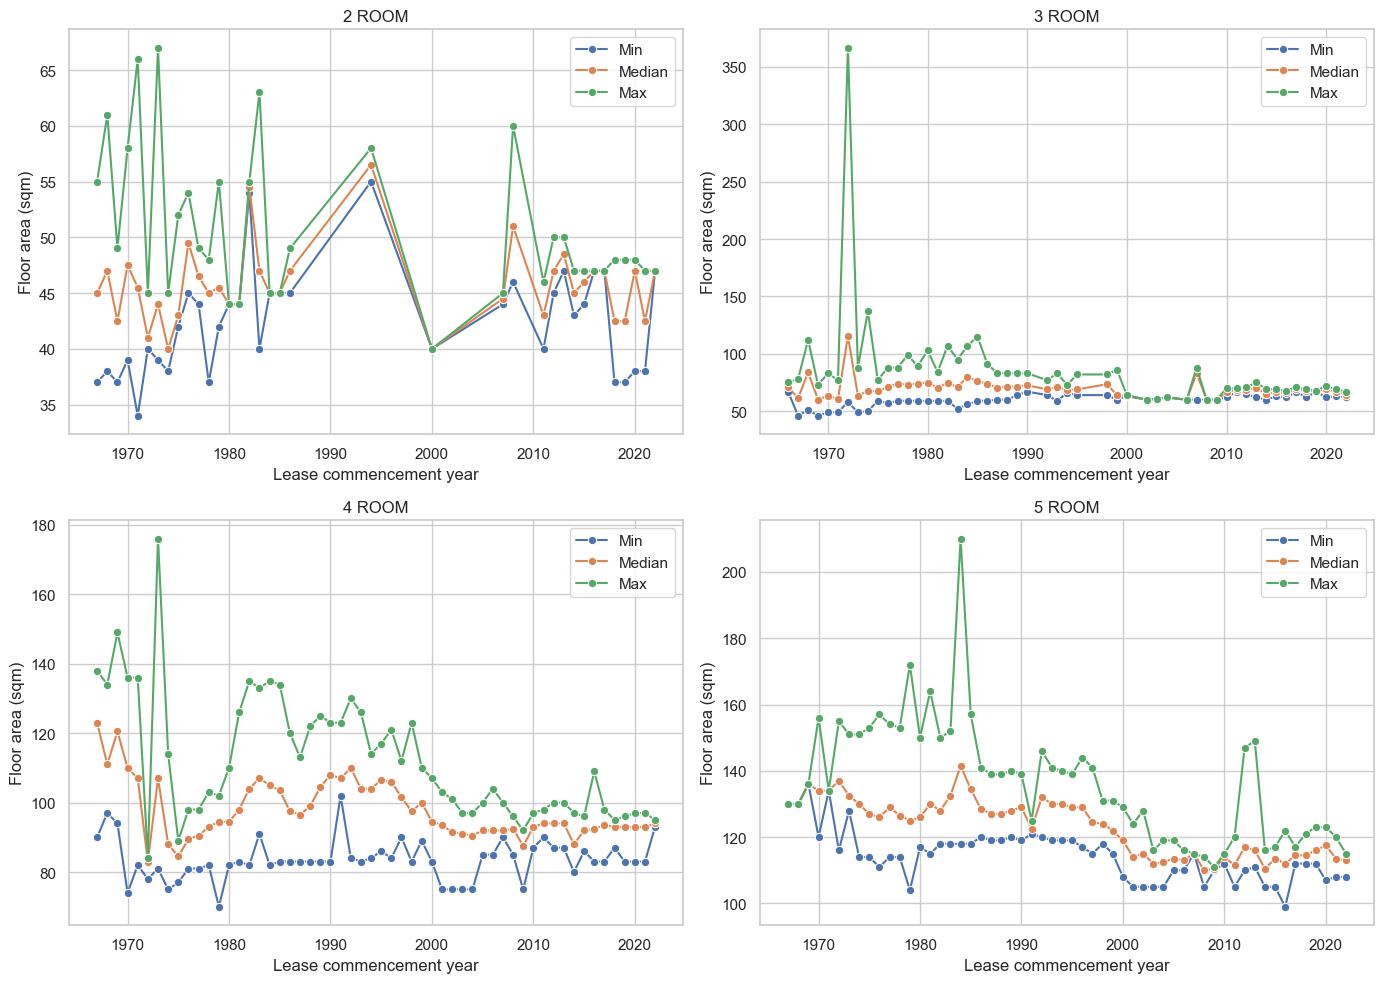

In [8]:
import seaborn as sns

sns.set_theme(style="whitegrid")

flat_types = ["2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

for ax, ft in zip(axes.flat, flat_types):
    sub = filtered_df[filtered_df["flat_type"] == ft].sort_values("lease_commence_date")
    sns.lineplot(data=sub, x="lease_commence_date", y="min_floor_area", ax=ax, label="Min", marker="o")
    sns.lineplot(data=sub, x="lease_commence_date", y="median_floor_area", ax=ax, label="Median", marker="o")
    sns.lineplot(data=sub, x="lease_commence_date", y="max_floor_area", ax=ax, label="Max", marker="o")
    ax.set_title(ft)
    ax.set_xlabel("Lease commencement year")
    ax.set_ylabel("Floor area (sqm)")
    ax.legend()

fig.tight_layout()
plt.show()

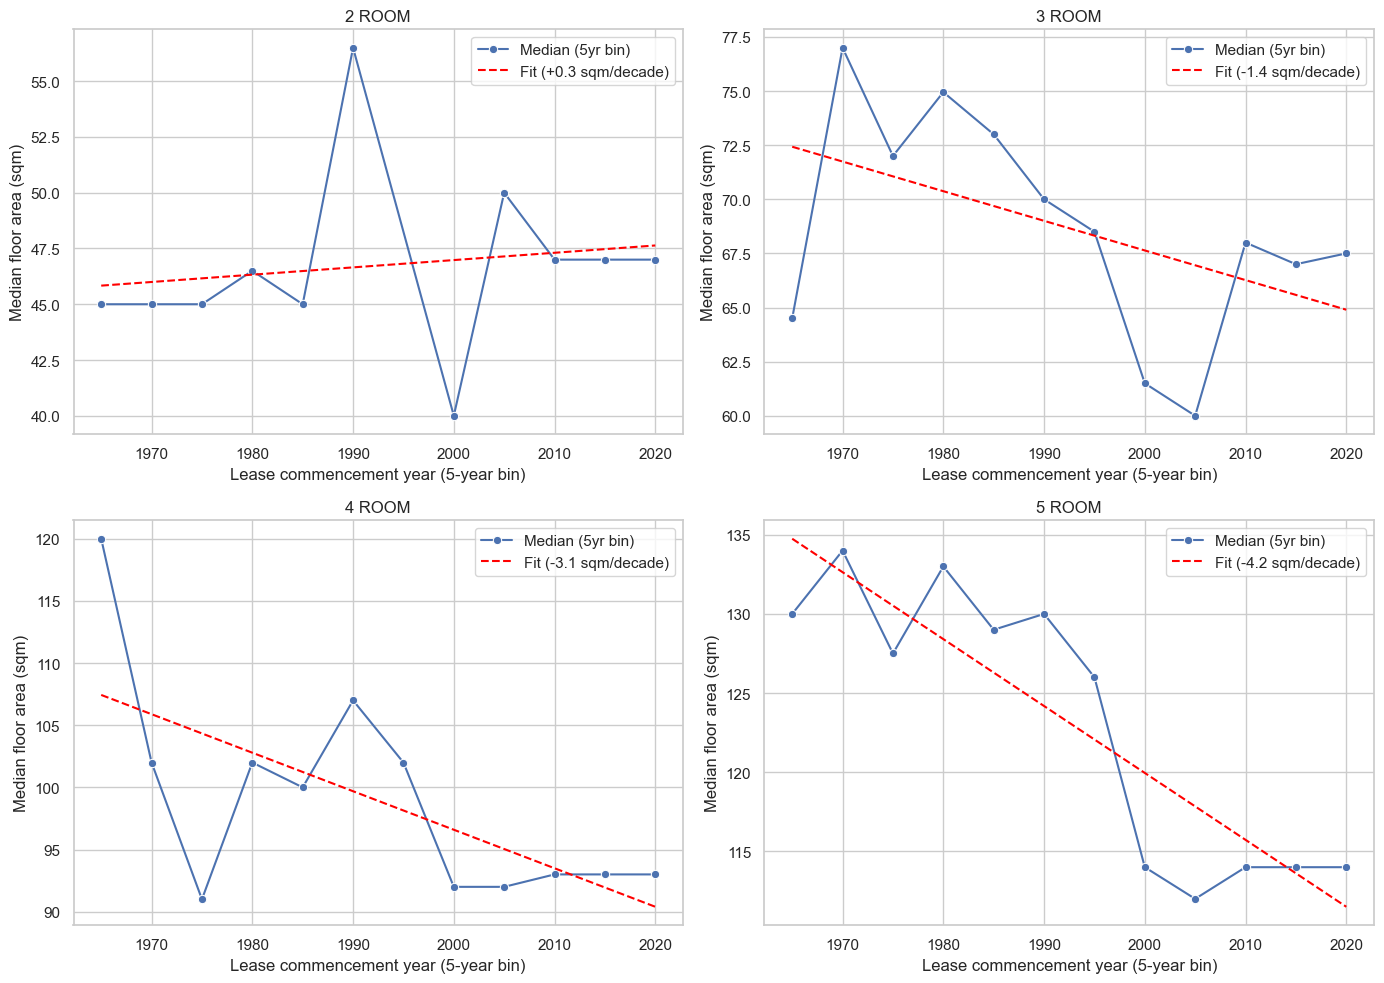

In [9]:
binned_df = subset_df[subset_df["flat_type"].isin(flat_types)].copy()
binned_df["year_bin"] = (binned_df["lease_commence_date"] // 5) * 5

binned_grouped = binned_df.groupby(["flat_type", "year_bin"])["floor_area_sqm"].median().reset_index(
    name="median_floor_area"
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=False)

for ax, ft in zip(axes.flat, flat_types):
    sub = binned_grouped[binned_grouped["flat_type"] == ft].sort_values("year_bin")

    slope, intercept = np.polyfit(sub["year_bin"], sub["median_floor_area"], 1)
    fit_y = slope * sub["year_bin"] + intercept

    sns.lineplot(data=sub, x="year_bin", y="median_floor_area", ax=ax, label="Median (5yr bin)", marker="o")
    ax.plot(sub["year_bin"], fit_y, linestyle="--", color="red", label=f"Fit ({slope*10:+.1f} sqm/decade)")

    ax.set_title(ft)
    ax.set_xlabel("Lease commencement year (5-year bin)")
    ax.set_ylabel("Median floor area (sqm)")
    ax.legend()

fig.tight_layout()
plt.show()

For 3, 4 and 5 Room, there is a clear downward trend. 

For 2 Room, the trend actually shows going upwards, but this is dependent on start date. If we chose 1990 as a start date, then all 4 would show downward trend.